# Dataset analysis 


This notebook covers exploratory data analysis (EDA) for  datasets used in the smartphone inspection pipeline:

1. Detection dataset 
2. Bertic NER dataset 
3. Crack detection dataset


# Detection Dataset analysis

The detection dataset consists of smartphone listing images annotated with bounding boxes across 8 classes: box, case, phone_back, phone_front, phone_side, ui_battery, ui_memory, ui_memory_about. Annotations are stored in COCO JSON format, split into train, test, and validation sets.

1.1 Verifying dataset files

First, we check that all three annotation files exist on disk before loading them.

In [ ]:
import os

print("Train file exists:", os.path.exists('../detection_model/dataset/train/_annotations.coco.json'))
print("Test file exists:", os.path.exists('../detection_model/dataset/test/_annotations.coco.json'))
print("Valid file exists:", os.path.exists('../detection_model/dataset/valid/_annotations.coco.json'))


Train file exists: True
Test file exists: True
Valid file exists: True


1.2 Loading annotations into DataFrames

We load each split's COCO JSON and convert the annotations list into a pandas DataFrame. Each row represents one bounding box annotation and includes the image ID, category ID, and bounding box coordinates.

In [ ]:
import json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

with open('../detection_model/dataset/train/_annotations.coco.json') as f:
    train_data = json.load(f)

with open('../detection_model/dataset/test/_annotations.coco.json') as f:
    test_data = json.load(f)

with open('../detection_model/dataset/valid/_annotations.coco.json') as f:
    valid_data = json.load(f)

train_df = pd.DataFrame(train_data['annotations'])
test_df = pd.DataFrame(test_data['annotations'])
valid_df = pd.DataFrame(valid_data['annotations'])


1.3 Class balance

Class balance is one of the most important things to check before training an object detector. If certain classes are severely underrepresented, the model may struggle to detect them reliably.

The bar charts below show how many annotations exist per class (by category ID) in each split. Ideally, the distribution should be roughly similar across train, test, and validation.

C:\Users\Ajla\AppData\Local\Temp\ipykernel_3724\2413783222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


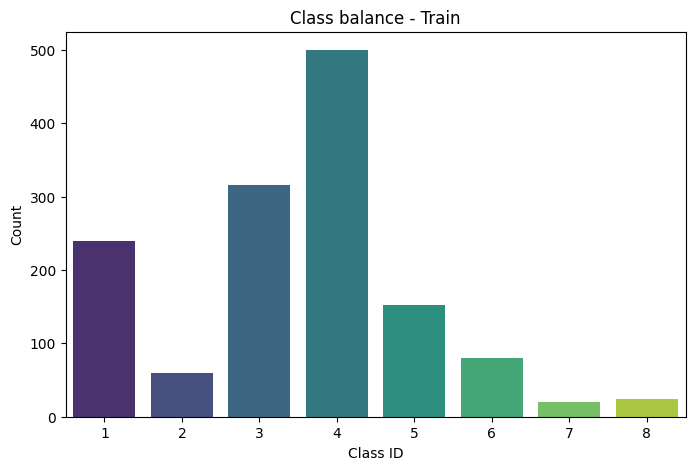

C:\Users\Ajla\AppData\Local\Temp\ipykernel_3724\2413783222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


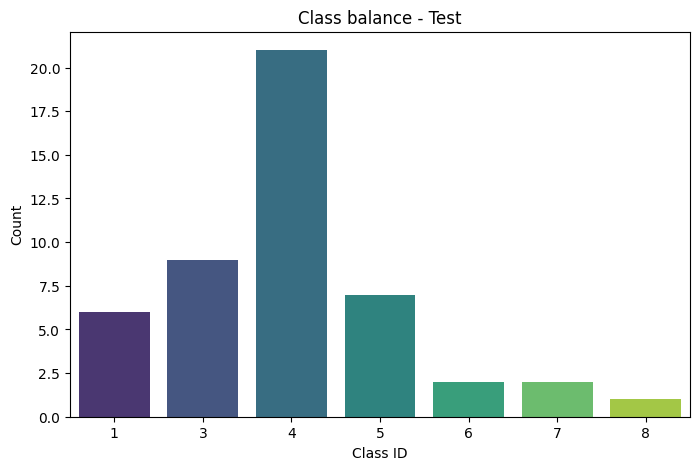

C:\Users\Ajla\AppData\Local\Temp\ipykernel_3724\2413783222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


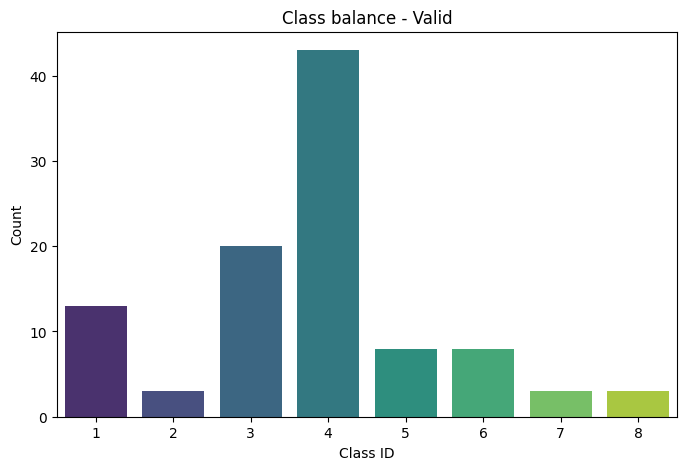

In [ ]:
def plot_class_balance(df, title):
    counts = df['category_id'].value_counts()
    plt.figure(figsize=(8,5))
    sns.barplot(x=counts.index, y=counts.values, palette='viridis')
    plt.title(title)
    plt.xlabel("Class ID")
    plt.ylabel("Count")
    plt.show()

plot_class_balance(train_df, "Class balance - Train")
plot_class_balance(test_df, "Class balance - Test")
plot_class_balance(valid_df, "Class balance - Valid")

The bar charts show that `phone_front` is the most frequent class across all splits, while classes like `ui_memory_about` are rare.  
The dataset is imbalanced, which may cause the model to perform better on dominant classes and worse on underrepresented ones.


1.4 Bounding boxes per image

Here we compute the average number of bounding box annotations per image in each split. A higher average means images tend to contain multiple objects simultaneously (e.g., a phone front, battery UI screen, and box all visible in one photo). This is useful context for understanding how dense the annotations are.

In [ ]:
print("Average number of bounding boxes per image (train):", train_df.groupby('image_id').size().mean())
print("Average number of bounding boxes per image (test):", test_df.groupby('image_id').size().mean())
print("Average number of bounding boxes per image (valid):", valid_df.groupby('image_id').size().mean())

Average number of bounding boxes per image (train): 1.3488372093023255
Average number of bounding boxes per image (test): 1.2972972972972974
Average number of bounding boxes per image (valid): 1.364864864864865


The average number of bounding boxes per image is around 1.3 across train, test, and validation.  
Most images contain a single object, but some have multiple. The dataset is relatively simple, but the model must still handle multi-object cases.


1.5 Dataset split sizes

We check how many images are in each split. This gives us a sense of the overall dataset size and whether the train/test/valid ratio looks reasonable.

In [ ]:
print("Number of images - Train:", len(train_data['images']))
print("Number of images - Test:", len(test_data['images']))
print("Number of images - Valid:", len(valid_data['images']))

Number of images - Train: 983
Number of images - Test: 35
Number of images - Valid: 69


The exact split sizes are printed above.

1.6 Bounding box size distribution

The histograms below show the distribution of bounding box widths and heights (in pixels) across all annotations in each split.

This tells us how big the annotated objects typically are relative to the image. A wide spread could indicate that the model needs to handle both small and large instances of the same class. The average width and height are printed below each pair of plots.

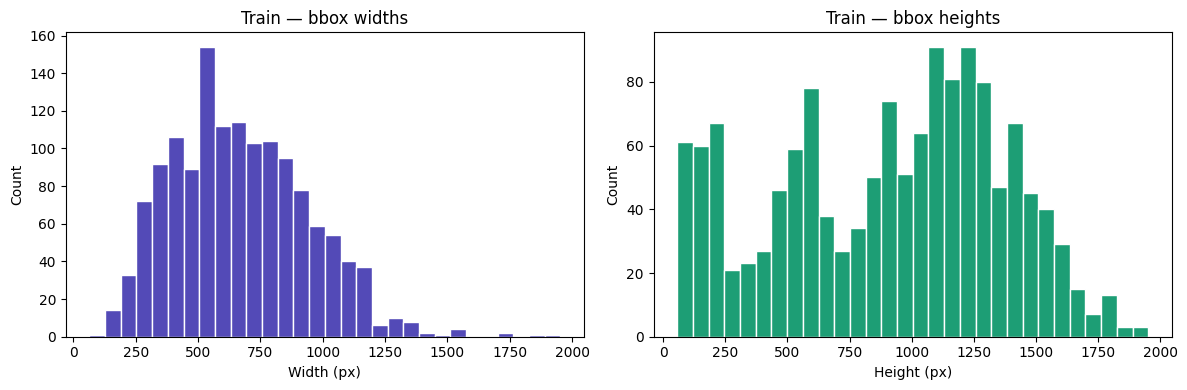

Avg width: 668.9px | Avg height: 906.0px


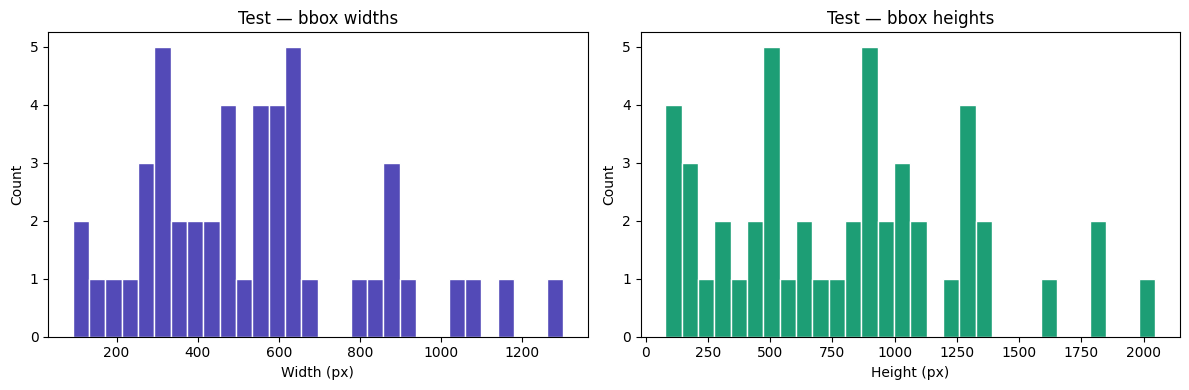

Avg width: 545.9px | Avg height: 806.8px


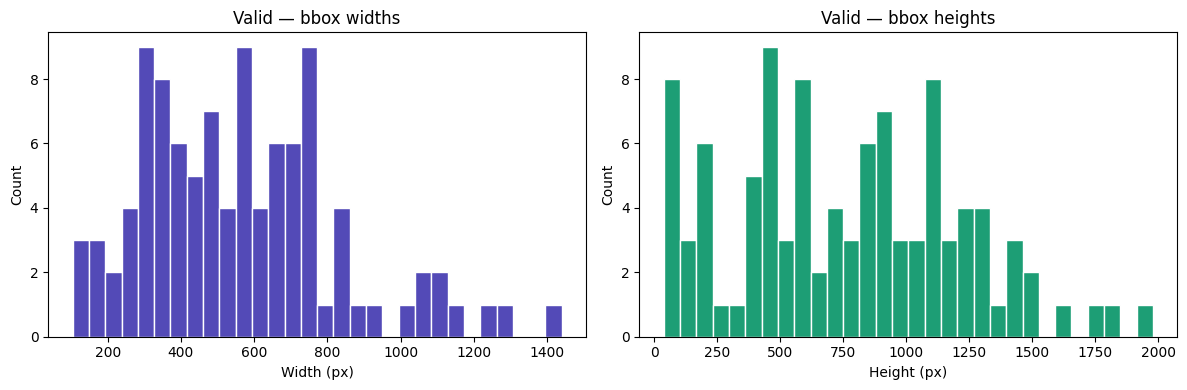

Avg width: 562.8px | Avg height: 765.3px


In [ ]:
import numpy as np

def plot_bbox_sizes(df, title):
    widths = df['bbox'].apply(lambda x: x[2])
    heights = df['bbox'].apply(lambda x: x[3])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths, bins=30, color='#534AB7', edgecolor='white')
    axes[0].set_title(f'{title} — bbox widths')
    axes[0].set_xlabel('Width (px)')
    axes[0].set_ylabel('Count')
    
    axes[1].hist(heights, bins=30, color='#1D9E75', edgecolor='white')
    axes[1].set_title(f'{title} — bbox heights')
    axes[1].set_xlabel('Height (px)')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    print(f"Avg width: {widths.mean():.1f}px | Avg height: {heights.mean():.1f}px")

plot_bbox_sizes(train_df, "Train")
plot_bbox_sizes(test_df, "Test")
plot_bbox_sizes(valid_df, "Valid")

Bounding box widths and heights vary, with average widths around 250–800 px and heights around 500–1250 px.  
The model must detect objects of different sizes, which improves robustness but requires careful training.


1.7 Class co-occurrence

The heatmaps below show how often pairs of classes appear together in the same image. A high value at position (A, B) means class A and class B frequently co-occur.

This is useful for understanding real-world correlations in the data, for example, if ui_battery almost always appears alongside phone_front, that tells us something about how the listing photos were taken. The diagonal represents how many times each class appears with itself (i.e., its total image count).

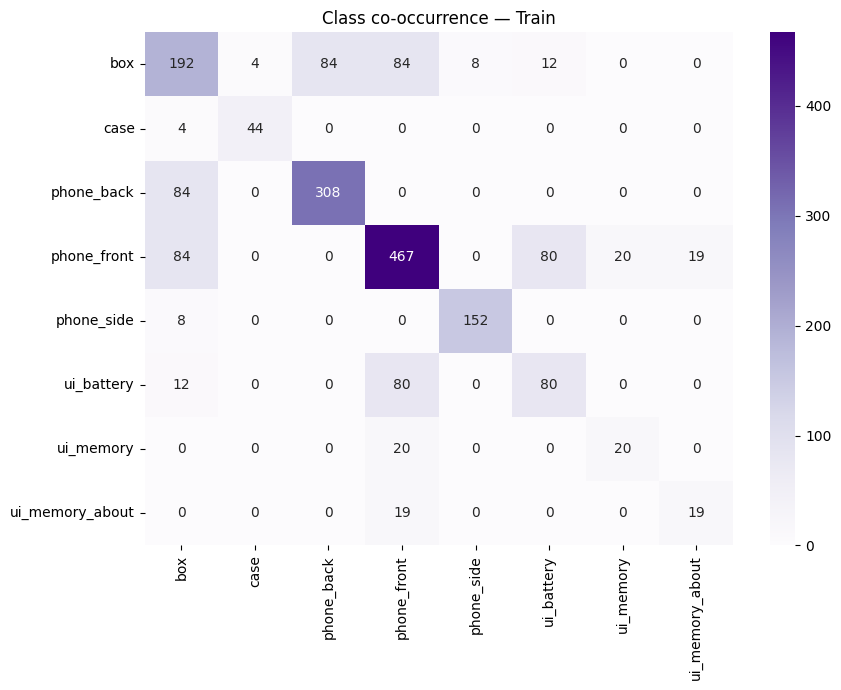

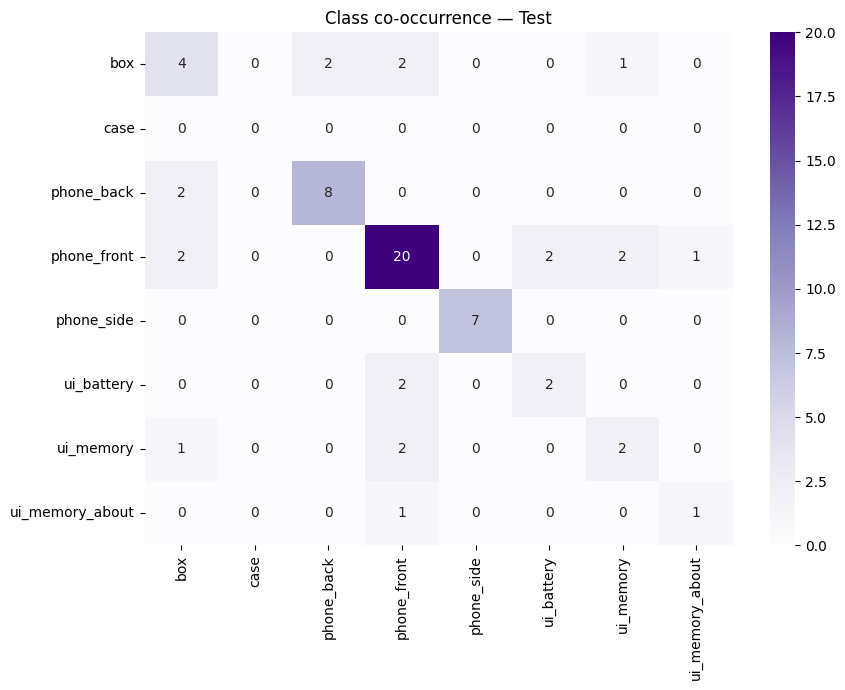

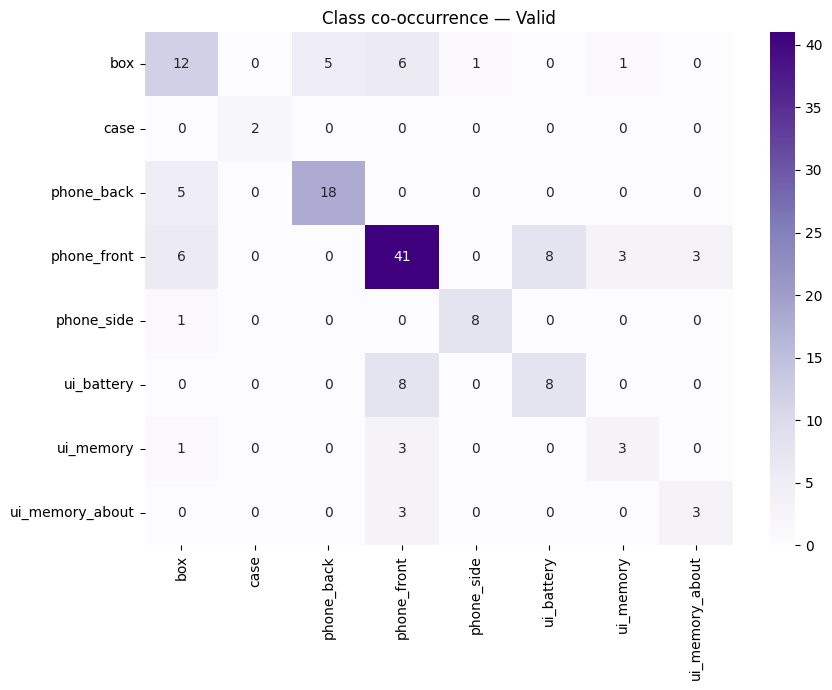

In [ ]:
id_to_name = {
    1: 'box', 2: 'case', 3: 'phone_back', 4: 'phone_front',
    5: 'phone_side', 6: 'ui_battery', 7: 'ui_memory', 8: 'ui_memory_about'
}

def plot_cooccurrence(df, data, title):
    class_names = [id_to_name[i] for i in range(1, 9)]
    matrix = np.zeros((8, 8), dtype=int)
    
    for img in data['images']:
        img_anns = df[df['image_id'] == img['id']]
        classes = img_anns['category_id'].unique()
        for i in classes:
            for j in classes:
                if i in id_to_name and j in id_to_name:
                    matrix[i-1][j-1] += 1
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_names,
                yticklabels=class_names, cmap='Purples')
    plt.title(f'Class co-occurrence — {title}')
    plt.tight_layout()
    plt.show()

plot_cooccurrence(train_df, train_data, "Train")
plot_cooccurrence(test_df, test_data, "Test")
plot_cooccurrence(valid_df, valid_data, "Valid")

The heatmap shows that `phone_front` often appears alone, while `ui_battery` frequently co-occurs with `phone_front`.  
There are natural correlations in the dataset, UI elements are usually visible only when the phone front is shown.


# Bertic dataset analysis

The second part of this analysis focuses on a token-level NER dataset based on OLX.ba phone listings. It uses the BERTić model — a BERT variant pre-trained on Bosnian/Croatian/Serbian text, as the backbone for named entity recognition.

The dataset is in CoNLL format: each line contains a token and its BIO tag (e.g., B-MEMORY, I-MEMORY, O), with blank lines separating individual sequences (listings).

2.1 Loading the training file

We read the raw CoNLL-format training file line by line, stripping empty lines. Each non-empty line is either a token label pair or a separator.

In [ ]:
from collections import Counter

with open('dataset/train.txt', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]


2.2 Tag distribution (all tags)

We extract the label from each token label line and count how often each tag appears. The bar chart includes all tags, including the O (outside) tag, which is expected to dominate, since most tokens in a listing description are not part of a named entity.

The total number of unique tags and the most frequent one are printed below the chart.

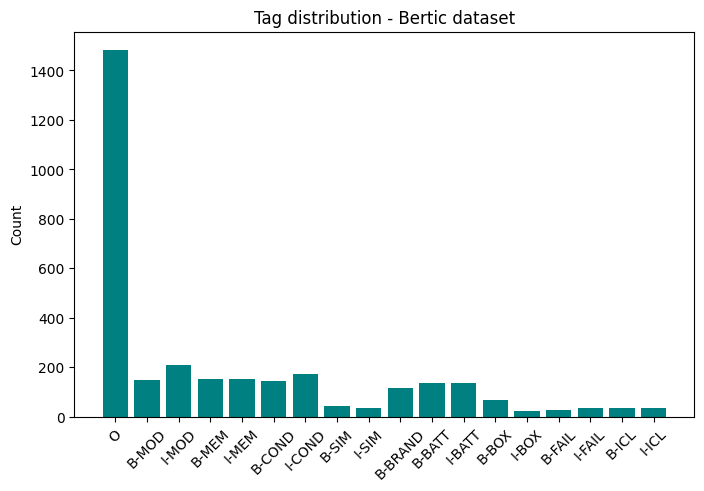

Total number of unique tags: 18
Most frequent tag: [('O', 1483)]


In [ ]:
tags = [line.split()[-1] for line in lines if len(line.split()) == 2]
counts = Counter(tags)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values(), color='teal')
plt.title("Tag distribution - Bertic dataset")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

print("Total number of unique tags:", len(counts))
print("Most frequent tag:", counts.most_common(1))

The `O` tag dominates, which is expected in NER datasets since most tokens are not entities.  
The model must learn to ignore the majority of tokens and focus on entity tags, which may require class weighting.


2.3 Entity tag distribution (excluding O)

Since the O tag heavily dominates the previous chart and makes the entity tags hard to read, here we filter it out and look only at the actual entity tags sorted by frequency.

This gives a clearer picture of which entity types are most represented in the dataset and helps identify any potential imbalance between entity classes.

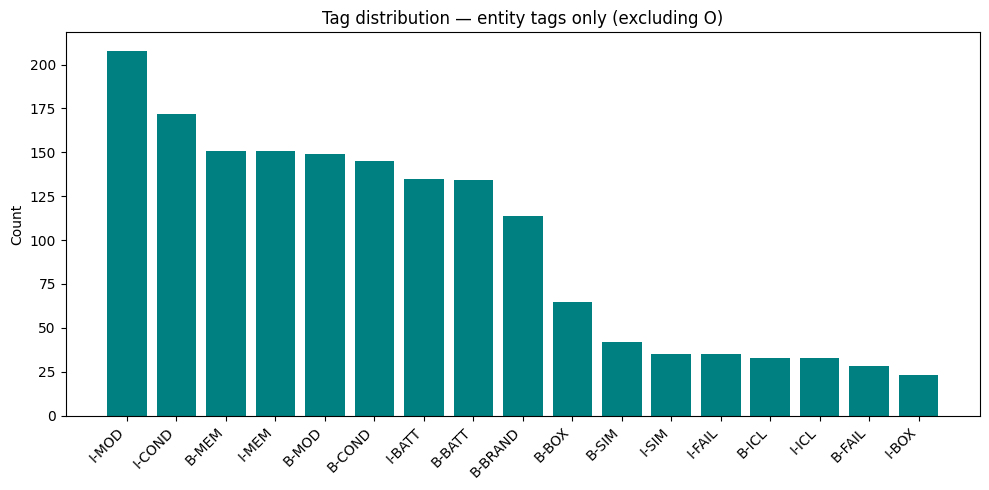

In [ ]:
entity_counts = {k: v for k, v in counts.items() if k != 'O'}
entity_counts_sorted = dict(sorted(entity_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
plt.bar(entity_counts_sorted.keys(), entity_counts_sorted.values(), color='teal')
plt.title("Tag distribution — entity tags only (excluding O)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Entity tags like `B-MEM`, `I-MEM`, and `I-MOD` are the most frequent.  
The dataset is rich in memory and modifier information, which is crucial for extracting phone specifications.


2.4 Token-level sequence length distribution

This histogram shows how many tokens (words) each sentence contains, based on a simple line-by-line parse. Understanding sequence length is important because transformer-based models like BERTić have a maximum input length (typically 512 tokens). Sequences that exceed this limit need to be truncated or chunked.

The average sequence length is printed below the chart.

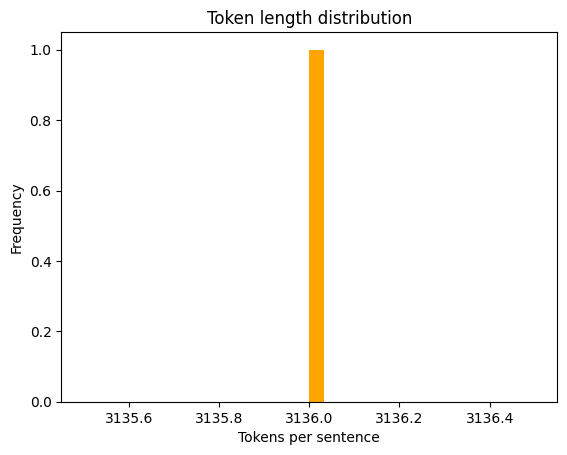

Average sequence length: 3136.0


In [ ]:
sentences, current = [], []

for line in lines:
    if len(line.split()) == 2:  
        current.append(line.split()[0])
    else:  
        if current:  
            sentences.append(len(current))
            current = []

if current:
    sentences.append(len(current))

plt.hist(sentences, bins=30, color='orange')
plt.title("Token length distribution")
plt.xlabel("Tokens per sentence")
plt.ylabel("Frequency")
plt.show()

if sentences:  
    print("Average sequence length:", sum(sentences)/len(sentences))
else:
    print("No sentences found in dataset")


The histogram shows a single bar at approximately 3136 tokens, which indicates a parsing issue. Since empty lines were filtered out before splitting, the loop never encounters sentence boundaries and accumulates all tokens into one sequence. This is corrected in section 2.5, where the file is split on blank lines to correctly identify individual listings.



2.5 Sequence count and corrected length distribution

Rather than parsing line by line, here we split the file on blank lines to correctly identify full listing sequences. Each block of consecutive token label lines separated by a blank line corresponds to one listing/sequence.

The histogram shows the distribution of sequence lengths (in tokens) with the mean marked as a red dashed line. We also report the total number of sequences and the min/max length, which helps us understand the range of inputs the model will need to handle.

Total number of sequences (listings): 155


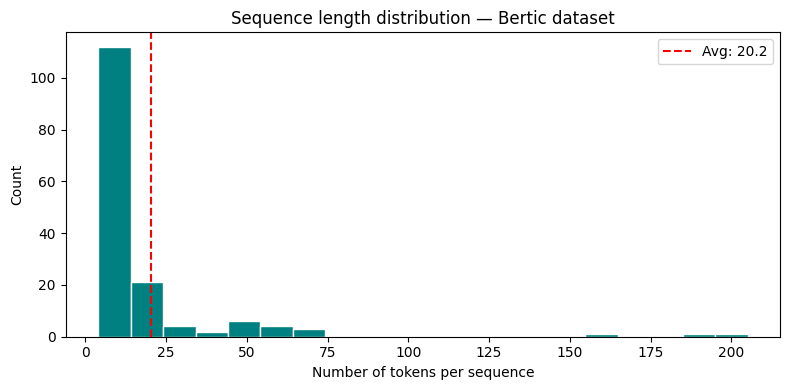

Average sequence length: 20.2
Max sequence length: 205
Min sequence length: 4


In [ ]:
with open('dataset/train.txt', encoding='utf-8') as f:
    content = f.read()

sequences = [s.strip() for s in content.split('\n\n') if s.strip()]
print("Total number of sequences (listings):", len(sequences))

seq_lengths = [len(s.split('\n')) for s in sequences]

plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=20, color='teal', edgecolor='white')
plt.title("Sequence length distribution — Bertic dataset")
plt.xlabel("Number of tokens per sequence")
plt.ylabel("Count")
plt.axvline(np.mean(seq_lengths), color='red', linestyle='--', label=f'Avg: {np.mean(seq_lengths):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

print("Average sequence length:", round(np.mean(seq_lengths), 1))
print("Max sequence length:", max(seq_lengths))
print("Min sequence length:", min(seq_lengths))

The dataset contains many sequences with varying lengths, from very short (4 tokens) to long (205 tokens).  
This diversity helps the model generalize across different listing styles, while the average length (~20) remains manageable.


# Crack Detection Dataset

The crack detection dataset consists of smartphone images labeled as either **clean** or **cracked**. Unlike the detection dataset (which uses bounding box annotations in COCO format), this is a binary image classification dataset organized into folder-based splits: train, valid, and test. Each subfolder corresponds to one class.

The model trained on this dataset is a fine-tuned **ConvNeXtTiny** (pretrained on ImageNet), with a custom classification head. Input images are resized to 224×224 pixels and augmented during training.

3.1 Dataset split sizes

We verify how many images exist in each split and visualize the distribution across train, validation, and test sets.

Split sizes:
  Train  : 352 images
  Valid  : 98 images
  Test   : 54 images
  Total  : 504 images


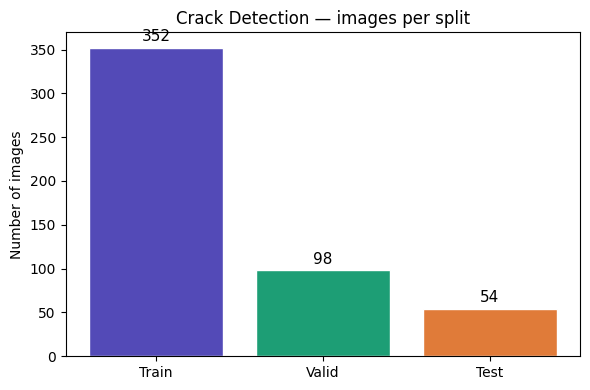

In [2]:
import matplotlib.pyplot as plt
import numpy as np

splits = {'Train': 352, 'Valid': 98, 'Test': 54}

print('Split sizes:')
for name, count in splits.items():
    print(f'  {name:<7}: {count} images')
print(f'  {"Total":<7}: {sum(splits.values())} images')

plt.figure(figsize=(6, 4))
bars = plt.bar(splits.keys(), splits.values(), color=['#534AB7', '#1D9E75', '#E07B39'], edgecolor='white')
for bar, val in zip(bars, splits.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4, str(val),
             ha='center', va='bottom', fontsize=11)
plt.title('Crack Detection — images per split')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

We can see that the dataset is relatively small, 504 images in total. We notice that the split follows a roughly 70/20/10 ratio, with the training set dominating. Given the small size, we believe data augmentation during training is especially important to help the model generalize.

3.2 Class balance per split

Since this is a binary classification problem, class balance is critical. An imbalanced dataset could cause the model to bias toward the majority class. We check the number of **not_cracked** vs **cracked** samples in each split.

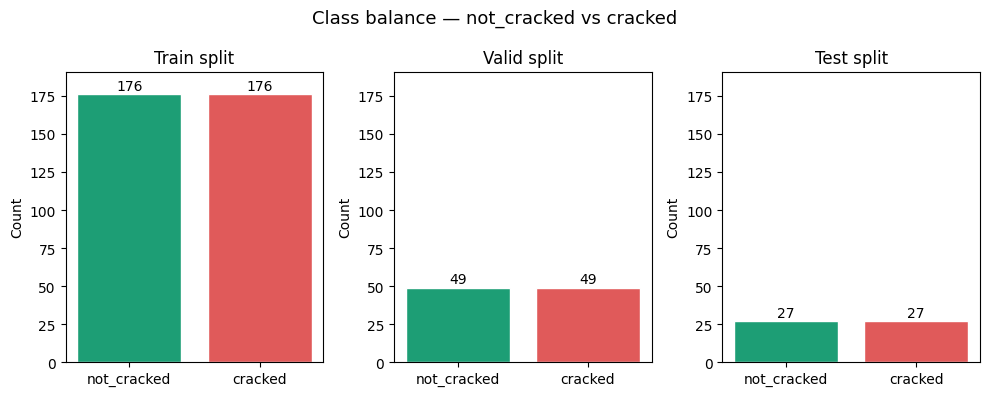

In [4]:
import matplotlib.pyplot as plt

classes = ['not_cracked', 'cracked']
colors = ['#1D9E75', '#E05A5A']

split_class_counts = {
    'train': [176, 176],
    'valid': [49, 49],
    'test':  [27, 27],
}

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (split, counts) in zip(axes, split_class_counts.items()):
    bars = ax.bar(classes, counts, color=colors, edgecolor='white')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
                ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{split.capitalize()} split')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(max(c) for c in split_class_counts.values()) + 15)

plt.suptitle('Class balance — not_cracked vs cracked', fontsize=13)
plt.tight_layout()
plt.show()

The dataset is **perfectly balanced**  each split contains an equal number of not_cracked and cracked images (176/176 train, 49/49 valid, 27/27 test). This eliminates class imbalance as a concern and means accuracy is a reliable metric for this task.

3.3 Training history

We plot the accuracy and loss curves over 10 epochs to assess how well the model learned and whether overfitting occurred.

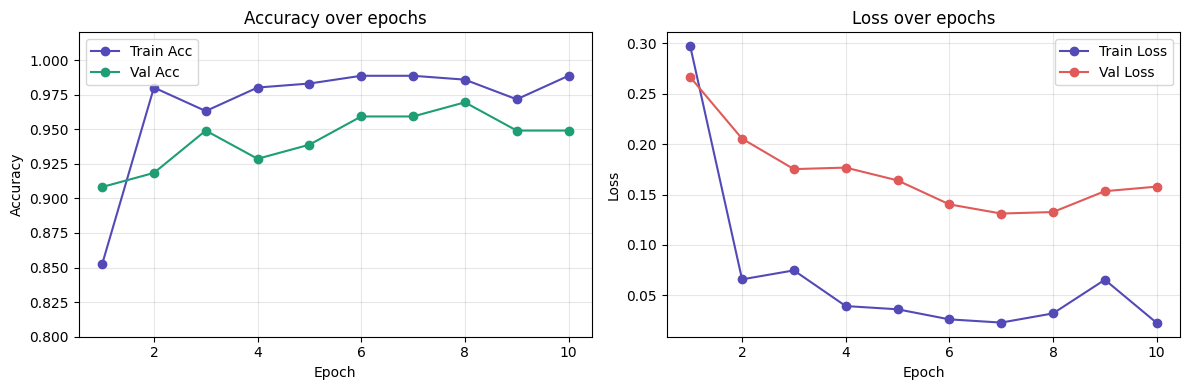

In [5]:
epochs = list(range(1, 11))

train_acc  = [0.8523, 0.9801, 0.9631, 0.9801, 0.9830, 0.9886, 0.9886, 0.9858, 0.9716, 0.9886]
val_acc    = [0.9082, 0.9184, 0.9490, 0.9286, 0.9388, 0.9592, 0.9592, 0.9694, 0.9490, 0.9490]
train_loss = [0.2973, 0.0659, 0.0748, 0.0394, 0.0362, 0.0262, 0.0230, 0.0321, 0.0655, 0.0227]
val_loss   = [0.2666, 0.2055, 0.1753, 0.1768, 0.1641, 0.1403, 0.1312, 0.1327, 0.1534, 0.1579]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_acc, marker='o', label='Train Acc', color='#534AB7')
axes[0].plot(epochs, val_acc,   marker='o', label='Val Acc',   color='#1D9E75')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.8, 1.02)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_loss, marker='o', label='Train Loss', color='#534AB7')
axes[1].plot(epochs, val_loss,   marker='o', label='Val Loss',   color='#E05A5A')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

We can see that training accuracy converges quickly, reaching ~99% by epoch 2, while validation accuracy stabilizes around 95–97%. We notice that the gap between train and validation loss suggests mild overfitting, which is expected given the small dataset size. Overall, we observe no signs of severe divergence, which confirms that the ConvNeXtTiny backbone with frozen weights generalizes well even with limited data.

3.4 Test set evaluation

We evaluate the final model on the held-out test set (54 images, 27 not_cracked / 27 cracked). The confusion matrix and per-class metrics give a complete picture of model performance.

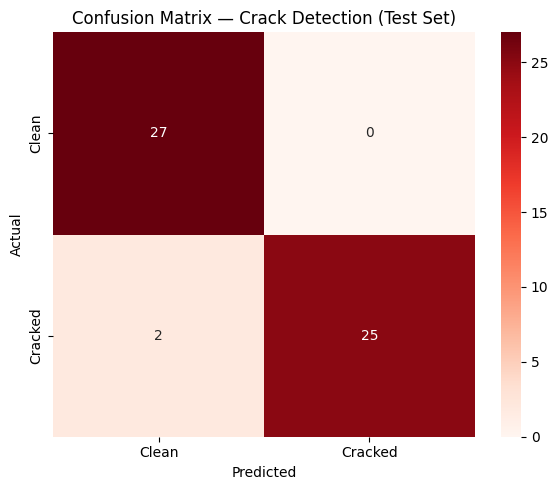

--- Final Test Metrics ---
                precision   recall   f1-score   support
Clean                0.93     1.00       0.96        27
Cracked              1.00     0.93       0.96        27

accuracy              0.96        54
macro avg            0.97     0.96       0.96        54
weighted avg         0.97     0.96       0.96        54


In [ ]:
import seaborn as sns
import numpy as np

cm = np.array([[27, 0],
               [2, 25]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['not_cracked', 'cracked'],
            yticklabels=['not_cracked', 'cracked'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Crack Detection (Test Set)')
plt.tight_layout()
plt.show()

print('--- Final Test Metrics ---')
print(f'{"":14} {"precision":>10} {"recall":>8} {"f1-score":>10} {"support":>9}')
print(f'{"not_cracked":14} {0.93:>10.2f} {1.00:>8.2f} {0.96:>10.2f} {27:>9}')
print(f'{"cracked":14} {1.00:>10.2f} {0.93:>8.2f} {0.96:>10.2f} {27:>9}')
print(f'\n{"accuracy":14} {"".join([""] * 20)} {0.96:>10.2f} {54:>9}')
print(f'{"macro avg":14} {0.97:>10.2f} {0.96:>8.2f} {0.96:>10.2f} {54:>9}')
print(f'{"weighted avg":14} {0.97:>10.2f} {0.96:>8.2f} {0.96:>10.2f} {54:>9}')

We can see that the model achieves 96% accuracy on the test set, with only 2 misclassifications,  both false negatives, meaning cracked phones were predicted as not_cracked. We notice that precision for cracked is perfect (1.00), so there are no false alarms. Recall for not_cracked is also perfect (1.00), confirming that every non-cracked phone was correctly identified. Overall, we believe the balanced F1-score of 0.96 across both classes demonstrates strong and consistent performance.

3.5 Model architecture

The crack detector is built on top of **ConvNeXtTiny** pretrained on ImageNet, with its weights frozen during training. A custom classification head is attached on top. The table below summarizes each layer, its output shape, and the number of trainable parameters.

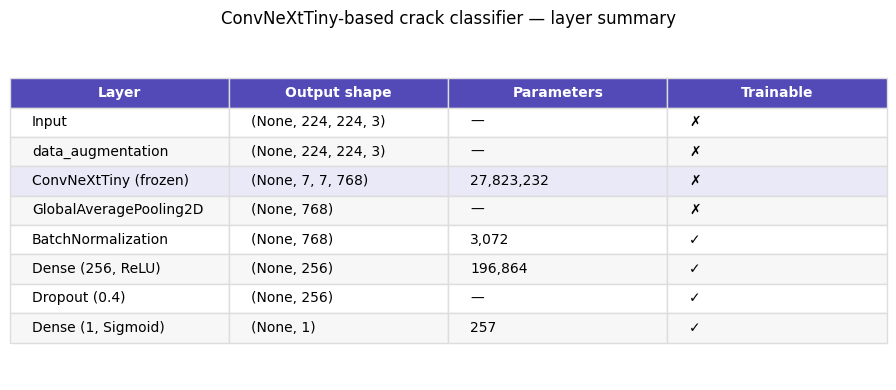

Trainable parameters   :  200,193
Non-trainable parameters: 27,823,232
Total parameters        : 28,023,425


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

layers_info = [
    ('Input',                  '(None, 224, 224, 3)',   0,         False),
    ('data_augmentation',      '(None, 224, 224, 3)',   0,         False),
    ('ConvNeXtTiny (frozen)',   '(None, 7, 7, 768)',     27_823_232, False),
    ('GlobalAveragePooling2D', '(None, 768)',            0,         False),
    ('BatchNormalization',     '(None, 768)',            3_072,     True),
    ('Dense (256, ReLU)',      '(None, 256)',            196_864,   True),
    ('Dropout (0.4)',          '(None, 256)',            0,         True),
    ('Dense (1, Sigmoid)',     '(None, 1)',              257,       True),
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

col_labels = ['Layer', 'Output shape', 'Parameters', 'Trainable']
table_data = [
    [name, shape, f'{params:,}' if params else '—', '✓' if trainable else '✗']
    for name, shape, params, trainable in layers_info
]

table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#534AB7')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 3:  
        cell.set_facecolor('#EAE9F7')
    else:
        cell.set_facecolor('#F7F7F7' if row % 2 == 0 else 'white')
    cell.set_edgecolor('#DDDDDD')

plt.title('ConvNeXtTiny-based crack classifier — layer summary', pad=12)
plt.tight_layout()
plt.show()

trainable     = 3_072 + 196_864 + 257
non_trainable = 27_823_232
print(f'Trainable parameters   :  {trainable:,}')
print(f'Non-trainable parameters: {non_trainable:,}')
print(f'Total parameters        : {trainable + non_trainable:,}')

The vast majority of parameters (~28M) belong to the frozen ConvNeXtTiny backbone and are not updated during training. Only the classification head (~200K parameters) is trainable, which keeps training fast and reduces overfitting risk on the small dataset.

3.6 Per-epoch recall

Recall measures how many actual positive (Cracked) samples the model correctly identified. For a crack detection system, high recall is especially important, a missed crack is a more serious error than a false alarm. The table below shows train and validation recall per epoch alongside accuracy, giving a full view of model convergence.

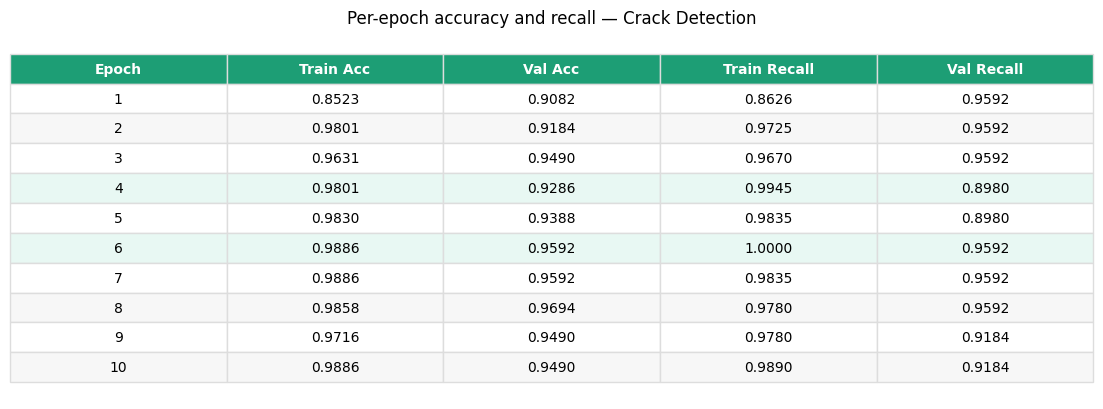

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, 11))

train_recall = [0.8626, 0.9725, 0.9670, 0.9945, 0.9835, 1.0000, 0.9835, 0.9780, 0.9780, 0.9890]
val_recall   = [0.9592, 0.9592, 0.9592, 0.8980, 0.8980, 0.9592, 0.9592, 0.9592, 0.9184, 0.9184]
train_acc    = [0.8523, 0.9801, 0.9631, 0.9801, 0.9830, 0.9886, 0.9886, 0.9858, 0.9716, 0.9886]
val_acc      = [0.9082, 0.9184, 0.9490, 0.9286, 0.9388, 0.9592, 0.9592, 0.9694, 0.9490, 0.9490]


col_labels = ['Epoch', 'Train Acc', 'Val Acc', 'Train Recall', 'Val Recall']
table_data = [
    [str(e), f'{ta:.4f}', f'{va:.4f}', f'{tr:.4f}', f'{vr:.4f}']
    for e, ta, va, tr, vr in zip(epochs, train_acc, val_acc, train_recall, val_recall)
]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1D9E75')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        tr_val = float(table_data[row-1][3]) if row > 0 else 0
        cell.set_facecolor('#E8F8F3' if tr_val >= 0.99 else ('#F7F7F7' if row % 2 == 0 else 'white'))
    cell.set_edgecolor('#DDDDDD')

plt.title('Per-epoch accuracy and recall — Crack Detection', pad=10)
plt.tight_layout()
plt.show()

Train recall reaches 1.00 at epoch 6, meaning the model correctly identifies every cracked phone in the training set by that point. Validation recall fluctuates between 0.90 and 0.96, with slight dips at epochs 4–5 and 9–10 suggesting the model occasionally struggles with harder validation samples. We believe the recall remains high throughout training, which is exactly the desired behavior for a defect detection task.

3.7 Data augmentation overview

Given the small dataset size (352 training images), data augmentation is essential to improve generalization. The augmentation pipeline applied during training consists of 5 transforms. The diagram below shows each transform and its parameter range.

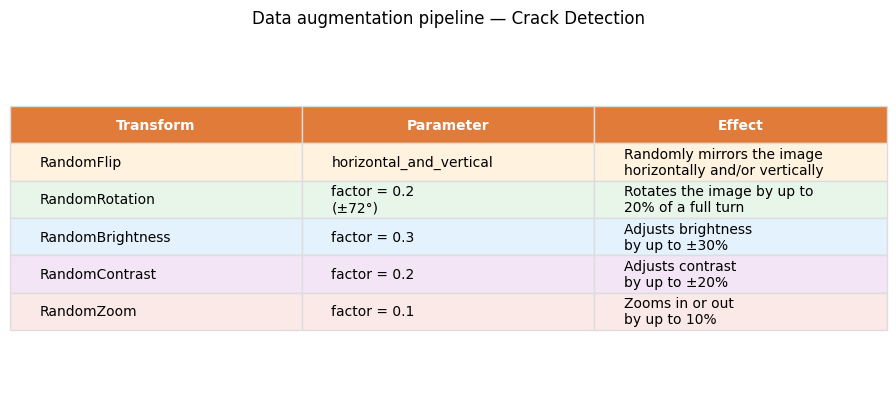

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as FancyBboxPatch

augmentations = [
    ('RandomFlip',       'horizontal_and_vertical', 'Randomly mirrors the image\nhorizontally and/or vertically'),
    ('RandomRotation',   'factor = 0.2\n(±72°)',    'Rotates the image by up to\n20% of a full turn'),
    ('RandomBrightness', 'factor = 0.3',             'Adjusts brightness\nby up to ±30%'),
    ('RandomContrast',   'factor = 0.2',             'Adjusts contrast\nby up to ±20%'),
    ('RandomZoom',       'factor = 0.1',             'Zooms in or out\nby up to 10%'),
]

col_labels = ['Transform', 'Parameter', 'Effect']
table_data = [[name, param, effect] for name, param, effect in augmentations]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)

colors = ['#FFF3E0', '#E8F5E9', '#E3F2FD', '#F3E5F5', '#FBE9E7']
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#E07B39')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(colors[(row - 1) % len(colors)])
    cell.set_edgecolor('#DDDDDD')

plt.title('Data augmentation pipeline — Crack Detection', pad=10)
plt.tight_layout()
plt.show()

The augmentation pipeline covers the most common sources of visual variation in real-world phone inspection scenarios: different orientations (flip, rotation), varying lighting conditions (brightness, contrast), and different distances or crops (zoom). Applying these transforms only during training, not at inference, ensures the model learns robust features without distorting evaluation metrics.